In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
# for dirname, _, filenames in os.walk('/kaggle/input'):
#     for filename in filenames:
#         print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [1]:
data_path = '/kaggle/input/chest-xray-pneumonia/chest_xray/'

train_path = data_path + 'train/'
valid_path = data_path + 'val/'
test_path = data_path + 'test/'

In [2]:
from glob import glob

print(f'훈련 데이터 개수 : {len(glob(train_path + "*/*"))}')
print(f'검증 데이터 개수 : {len(glob(valid_path + "*/*"))}')
print(f'테스트 데이터 개수 : {len(glob(test_path + "*/*"))}')

훈련 데이터 개수 : 5216
검증 데이터 개수 : 16
테스트 데이터 개수 : 624


In [3]:
glob(train_path + '*')

['/kaggle/input/chest-xray-pneumonia/chest_xray/train/PNEUMONIA',
 '/kaggle/input/chest-xray-pneumonia/chest_xray/train/NORMAL']

In [4]:
all_normal_imgs = []
all_pneumonia_imgs = []

for cat in ['train/', 'val/', 'test/']:
    data_cat_path = data_path + cat

    normal_imgs = glob(data_cat_path + 'NORMAL/*')
    pneumonia_imgs = glob(data_cat_path + 'PNEUMONIA/*')

    all_normal_imgs.extend(normal_imgs)
    all_pneumonia_imgs.extend(pneumonia_imgs)

print(f'정상 흉부 이미지 개수 : {len(all_normal_imgs)}')
print(f'폐렴 흉부 이미지 개수 : {len(all_pneumonia_imgs)}')

정상 흉부 이미지 개수 : 1583
폐렴 흉부 이미지 개수 : 4273


([<matplotlib.patches.Wedge at 0x7ec41742c610>,
 [Text(0.7266104793469584, 0.8258554421345079, 'Normal'),
  Text(-0.7266104020247887, -0.825855510164687, 'Pneumonia')],
 [Text(0.39633298873470457, 0.4504666048006406, '27.0%'),
  Text(-0.3963329465589756, -0.450466641908011, '73.0%')])

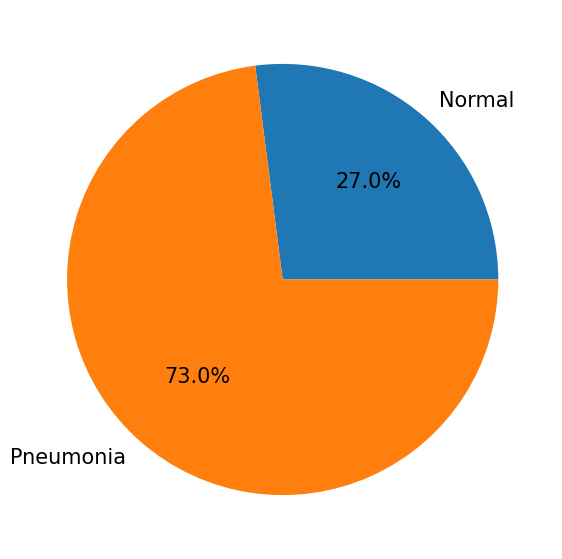

In [5]:
import matplotlib as mpl
import matplotlib.pyplot as plt
%matplotlib inline

mpl.rc('font', size=15)
plt.figure(figsize=(7, 7))

label = ['Normal', 'Pneumonia']

plt.pie([len(all_normal_imgs), len(all_pneumonia_imgs)],
       labels=label,
       autopct='%.1f%%')

In [6]:
import matplotlib.gridspec as gridspec
import cv2

def show_image(img_paths, rows=2, cols=3):
    assert len(img_paths) <= rows*cols

    mpl.rc('font', size=8)
    plt.figure(figsize=(15, 8))
    grid = gridspec.GridSpec(rows, cols)

    for idx, img_path in enumerate(img_paths):
        image = cv2.imread(img_path)
        ax = plt.subplot(grid[idx])
        ax.imshow(image)

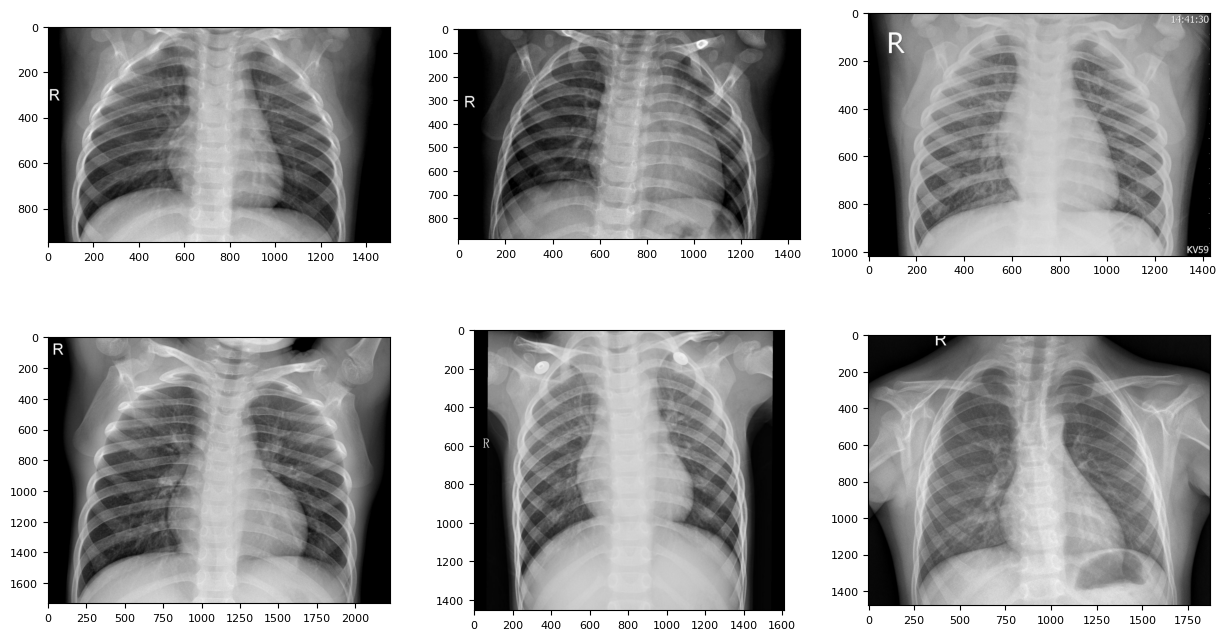

In [7]:
num_of_imgs = 6
normal_img_paths = all_normal_imgs[-num_of_imgs:]

show_image(normal_img_paths)

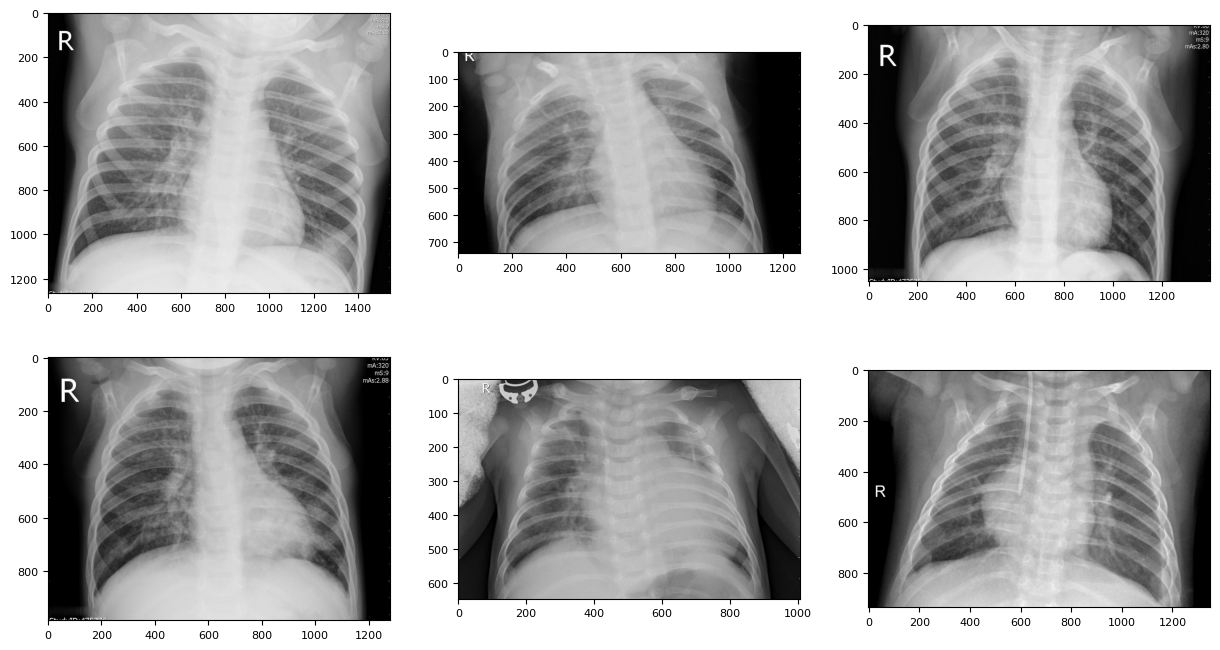

In [8]:
pneumonia_img_paths = all_pneumonia_imgs[-num_of_imgs:]

show_image(pneumonia_img_paths)

In [9]:
import torch
import random
import numpy as np
import os

seed = 50
os.environ['PYTHONHASHSEED'] = str(seed)
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
torch.cuda.manual_seed(seed)
torch.cuda.manual_seed_all(seed)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False
torch.backends.cudnn.enabled = False

In [10]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

In [11]:
from torchvision import transforms

transform_train = transforms.Compose([
    transforms.Resize((250, 250)),
    transforms.CenterCrop(180),
    transforms.RandomHorizontalFlip(0.5),
    transforms.RandomVerticalFlip(0.2),
    transforms.RandomRotation(20),
    transforms.ToTensor(),
    transforms.Normalize((0.485, 0.456, 0.406),
                        (0.229, 0.224, 0.225))
])

transform_test = transforms.Compose([
    transforms.Resize((250, 250)),
    transforms.CenterCrop(180),
    transforms.ToTensor(),
    transforms.Normalize((0.485, 0.456, 0.406),
                        (0.229, 0.224, 0.225))
])

In [12]:
from torchvision.datasets import ImageFolder

datasets_train = ImageFolder(root=train_path, transform=transform_train)

datasets_valid = ImageFolder(root=valid_path, transform=transform_test)

In [13]:
def seed_worker(worker_id):
    worker_seed = torch.initial_seed() % 2**32
    np.random.seed(worker_seed)
    random.seed(worker_seed)

g = torch.Generator()
g.manual_seed(0)

In [14]:
from torch.utils.data import DataLoader

batch_size = 8

loader_train = DataLoader(dataset=datasets_train, batch_size=batch_size, shuffle=True, worker_init_fn=seed_worker, generator=g, num_workers=2)
loader_valid = DataLoader(dataset=datasets_valid, batch_size=batch_size, shuffle=False, worker_init_fn=seed_worker, generator=g, num_workers=2)

In [15]:
!pip install efficientnet-pytorch

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.7 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 85.7 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 70.4 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 40.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.1 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 2.3 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 8.9 MB/s eta 0:00:000:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 13.2 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 8.2 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 83.0 MB/s eta 0:00:00:00:0100:01
  Created wheel for efficientnet-pytorch: filename=efficientnet

In [16]:
from efficientnet_pytorch import EfficientNet

model = EfficientNet.from_pretrained('efficientnet-b0', num_classes=2)

model = model.to(device)

Downloading: "https://github.com/lukemelas/EfficientNet-PyTorch/releases/download/1.0/efficientnet-b0-355c32eb.pth" to /root/.cache/torch/hub/checkpoints/efficientnet-b0-355c32eb.pth
100%|██████████| 20.4M/20.4M [00:00<00:00, 88.6MB/s]


Loaded pretrained weights for efficientnet-b0


In [17]:
print('모델 파라미터 개수 :', sum(param.numel() for param in model.parameters()))

모델 파라미터 개수 : 4010110


In [18]:
import torch.nn as nn

criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(model.parameters(), lr=0.01)

In [20]:
import torch

sample = torch.rand(4,2)
sample

tensor([[0.7864, 0.6544],
        [0.3683, 0.3547],
        [0.2639, 0.1648],
        [0.8977, 0.9484]])

In [21]:
torch.max(sample, dim=1)

torch.return_types.max(
values=tensor([0.7864, 0.3683, 0.2639, 0.9484]),
indices=tensor([0, 0, 0, 1]))

In [22]:
torch.max(sample, dim=1)[1]

tensor([0, 0, 0, 1])

In [27]:
from sklearn.metrics import accuracy_score, recall_score, f1_score
from tqdm.notebook import tqdm

def train(model, loader_train, loader_valid, criterion, optimizer, scheduler=None, epochs=10, save_file='model_state_dict.pth'):
    valid_loss_min = np.inf

    for epoch in range(epochs):
        print(f'에폭 [{epoch+1}/{epochs}] \n----------------------')

        model.train()
        epoch_train_loss = 0

        for images, labels in tqdm(loader_train):
            images = images.to(device)
            labels = labels.to(device)

            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            epoch_train_loss += loss.item()
            loss.backward()
            optimizer.step()
            if scheduler != None:
                scheduler.step()

        print(f'\t훈련 데이터 손실값 : {epoch_train_loss/len(loader_train):.4f}')

        model.eval()
        epoch_valid_loss = 0
        preds_list = []
        true_list = []

        with torch.no_grad():
            for images, labels in loader_valid:
                images = images.to(device)
                labels = labels.to(device)

                outputs = model(images)
                loss = criterion(outputs, labels)
                epoch_valid_loss += loss.item()

                preds = torch.max(outputs.cpu(), dim=1)[1].numpy()
                true = labels.cpu().numpy()

                preds_list.extend(preds)
                true_list.extend(true)

        print(f'\t검증 데이터 손실값 : {epoch_valid_loss/len(loader_valid):.4f}')

        val_accuracy = accuracy_score(true_list, preds_list)
        val_recall = recall_score(true_list, preds_list)
        val_f1_score = f1_score(true_list, preds_list)
        print(f'\t정확도 : {val_accuracy:.4f} / 재현율 : {val_recall:.4f} / F1 점수 : {val_f1_score:.4f}')

        if epoch_valid_loss <= valid_loss_min:
            print(f'\t### 검증 데이터 손실값 감소 ({valid_loss_min:.4f} --> {epoch_valid_loss:.4f}). 모델 저장')

            torch.save(model.state_dict(), save_file)
            valid_loss_min = epoch_valid_loss
    
    return torch.load(save_file)

In [28]:
model_state_dict = train(model=model, loader_train=loader_train,
                        loader_valid=loader_valid,
                        criterion=criterion,
                        optimizer=optimizer)

에폭 [1/10] 
----------------------


  0%|          | 0/652 [00:00<?, ?it/s]

	훈련 데이터 손실값 : 0.2669
	검증 데이터 손실값 : 2.3540
	정확도 : 0.5000 / 재현율 : 1.0000 / F1 점수 : 0.6667
	### 검증 데이터 손실값 감소 (inf --> 4.7080). 모델 저장
에폭 [2/10] 
----------------------


  0%|          | 0/652 [00:00<?, ?it/s]

	훈련 데이터 손실값 : 0.2397
	검증 데이터 손실값 : 1.2161
	정확도 : 0.6250 / 재현율 : 1.0000 / F1 점수 : 0.7273
	### 검증 데이터 손실값 감소 (4.7080 --> 2.4323). 모델 저장
에폭 [3/10] 
----------------------


...

	훈련 데이터 손실값 : 0.1451
	검증 데이터 손실값 : 2.9207
	정확도 : 0.5625 / 재현율 : 1.0000 / F1 점수 : 0.6957
에폭 [9/10] 
----------------------


  0%|          | 0/652 [00:00<?, ?it/s]

	훈련 데이터 손실값 : 0.1524
	검증 데이터 손실값 : 0.2876
	정확도 : 0.9375 / 재현율 : 1.0000 / F1 점수 : 0.9412
	### 검증 데이터 손실값 감소 (1.0344 --> 0.5752). 모델 저장
에폭 [10/10] 
----------------------


  0%|          | 0/652 [00:00<?, ?it/s]

	훈련 데이터 손실값 : 0.1315
	검증 데이터 손실값 : 0.5504
	정확도 : 0.6250 / 재현율 : 1.0000 / F1 점수 : 0.7273


In [29]:
model.load_state_dict(model_state_dict)

<All keys matched successfully>

In [30]:
datasets_test = ImageFolder(root=test_path, transform=transform_test)

loader_test = DataLoader(dataset=datasets_test, batch_size=batch_size,
                        shuffle=False, worker_init_fn=seed_worker,
                        generator=g, num_workers=2)

In [31]:
def predict(model, loader_test, return_true=False):
    model.eval()
    preds_list = []
    true_list = []

    with torch.no_grad():
        for images, labels in loader_test:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)

            preds = torch.max(outputs.cpu(), dim=1)[1].numpy()
            true = labels.cpu().numpy()

            preds_list.extend(preds)
            true_list.extend(true)

    if return_true:
        return true_list, preds_list
    else:
        return preds_list

In [32]:
true_list, preds_list = predict(model=model,
                               loader_test=loader_test,
                               return_true=True)

In [33]:
print('#'*5, '최종 예측 결과 평가 점수', '#'*5)
print(f'정확도 : {accuracy_score(true_list, preds_list):.4f}')
print(f'재현율 : {recall_score(true_list, preds_list):.4f}')
print(f'F1 점수 : {f1_score(true_list, preds_list):.4f}')

##### 최종 예측 결과 평가 점수 #####
정확도 : 0.8670
재현율 : 0.8949
F1 점수 : 0.8937
